<a href="https://colab.research.google.com/github/cd3004/CNN-Lab-Assignment/blob/main/24cd3004_CNN_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Task 1: Environment Setup & Data Pipeline

## Problem 1: Environment Verification

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib
import random

# Setting seeds
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# Versions
print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)

# GPU check
print("GPU:", tf.config.list_physical_devices('GPU'))

# Explanation:
# CPU is slower because it performs sequential computation.
# GPU is faster due to parallel processing using multiple cores.
# Seeds ensure reproducibility of random operations.

TensorFlow: 2.19.0
NumPy: 2.0.2
Pandas: 2.2.2
Matplotlib: 3.10.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
## Problem 2: Dataset Exploration


In [2]:
from tensorflow.keras.datasets import mnist, cifar10
import numpy as np

(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data()
(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = cifar10.load_data()

print("MNIST Train Shape:", x_train_mnist.shape)
print("MNIST Test Shape:", x_test_mnist.shape)

print("CIFAR Train Shape:", x_train_cifar.shape)
print("CIFAR Test Shape:", x_test_cifar.shape)

print("MNIST dtype:", x_train_mnist.dtype, "Range:", x_train_mnist.min(), "-", x_train_mnist.max())
print("CIFAR dtype:", x_train_cifar.dtype, "Range:", x_train_cifar.min(), "-", x_train_cifar.max())

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
MNIST Train Shape: (60000, 28, 28)
MNIST Test Shape: (10000, 28, 28)
CIFAR Train Shape: (50000, 32, 32, 3)
CIFAR Test Shape: (10000, 32, 32, 3)
MNIST dtype: uint8 Range: 0 - 255
CIFAR dtype: uint8 Range: 0 - 255


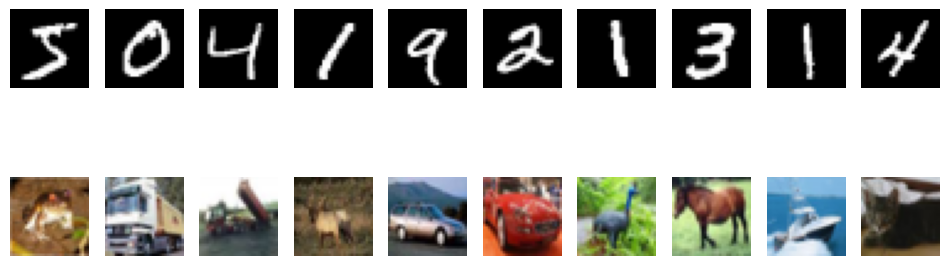

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

for i in range(10):
    plt.subplot(2,10,i+1)
    plt.imshow(x_train_mnist[i], cmap='gray')
    plt.axis('off')

    plt.subplot(2,10,i+11)
    plt.imshow(x_train_cifar[i])
    plt.axis('off')

plt.savefig("dataset_samples.png")
plt.show()

### Answer:

MNIST training data shape is (60000, 28, 28) and test data is (10000, 28, 28).
CIFAR-10 training data shape is (50000, 32, 32, 3) and test data is (10000, 32, 32, 3).
The data type is uint8 and values range from 0 to 255.
The dataset is approximately balanced across classes.

In [ ]:
## Problem 3: Preprocessing Pipeline


In [ ]:
from tensorflow.keras.utils import to_categorical

# BEFORE
print("Before Shape:", x_train_mnist.shape)
print("Before Range:", x_train_mnist.min(), "-", x_train_mnist.max())

# Normalize
x_train_mnist = x_train_mnist / 255.0
x_test_mnist = x_test_mnist / 255.0

# Reshape
x_train_mnist = x_train_mnist.reshape(-1,28,28,1)
x_test_mnist = x_test_mnist.reshape(-1,28,28,1)

# One-hot encoding
y_train_mnist = to_categorical(y_train_mnist, 10)
y_test_mnist = to_categorical(y_test_mnist, 10)

# AFTER
print("After Shape:", x_train_mnist.shape)
print("After Range:", x_train_mnist.min(), "-", x_train_mnist.max())

Before Shape: (60000, 28, 28)
Before Range: 0 - 255
After Shape: (60000, 28, 28, 1)
After Range: 0.0 - 1.0


### Answer:

The preprocessing pipeline normalizes pixel values to [0,1], reshapes the images to include a channel dimension, and converts labels into one-hot encoded vectors for classification.

In [ ]:
## Problem 4: Data Augmentation Pipeline

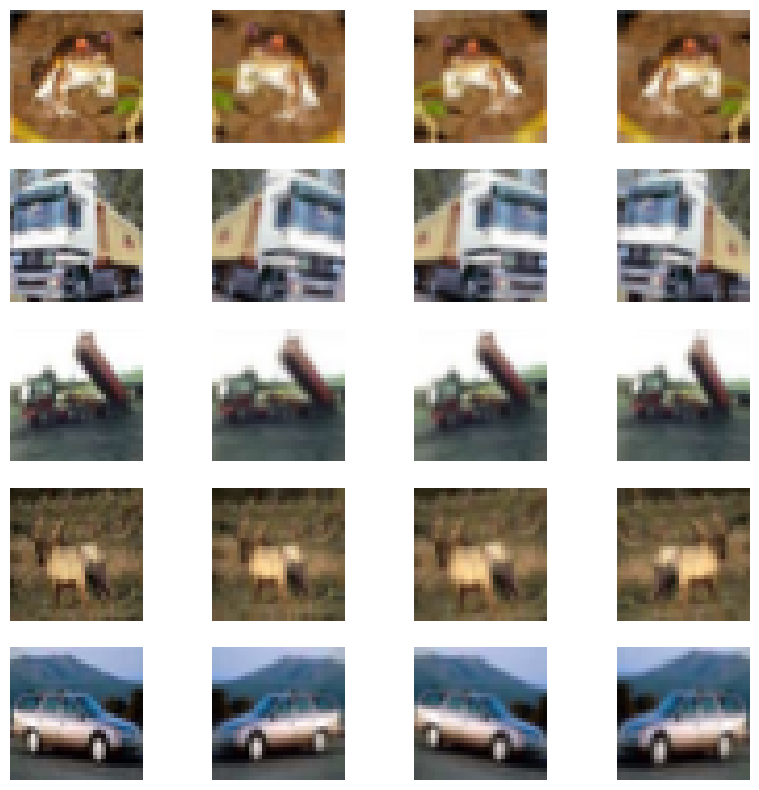

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

sample = x_train_cifar[:5]

plt.figure(figsize=(10,10))

for i in range(5):
    plt.subplot(5,4,i*4+1)
    plt.imshow(sample[i])
    plt.axis('off')

    aug = datagen.flow(sample[i:i+1], batch_size=1)

    for j in range(3):
        img = next(aug)[0]
        img = img / np.max(img)   # normalize to 0–1
        plt.subplot(5,4,i*4+j+2)
        plt.imshow(img)
        plt.axis('off')

plt.savefig("augmentation_demo.png")
plt.show()

### Answer:

Data augmentation is applied only to the training set to improve model generalization.
Applying it to validation or test data would distort evaluation results and lead to incorrect performance measurement.

## Analysis Questions

Q1: Channel represents number of color channels. Grayscale images have 1 channel, RGB images have 3 channels.

Q2: For large images, batch loading and data generators help reduce memory usage.

Q3: Using test statistics causes data leakage and leads to biased evaluation.

In [ ]:
# Task 2: Building a CNN from Scratch

## Problem 1: Manual 2D Convolution

In [ ]:
import numpy as np

def conv2d(image, kernel, stride=1, padding=0):
    image_padded = np.pad(image, padding, mode='constant')

    k = kernel.shape[0]
    output_size = (image_padded.shape[0] - k)//stride + 1

    output = np.zeros((output_size, output_size))

    for i in range(output_size):
        for j in range(output_size):
            region = image_padded[i:i+k, j:j+k]
            output[i,j] = np.sum(region * kernel)

    return output


# Test image
image = np.array([
    [3,1,0,2,4],
    [1,5,3,2,1],
    [0,2,6,4,3],
    [2,3,1,5,2],
    [1,0,2,3,4]
])

# Sobel kernel
kernel = np.array([
    [-1,0,1],
    [-2,0,2],
    [-1,0,1]
])

output = conv2d(image, kernel)

print("Output:\n", output)
print("Output Shape:", output.shape)

Output:
 [[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]
Output Shape: (3, 3)


### Answer:

The convolution operation applies a kernel over the image using element-wise multiplication and summation, producing a feature map. The output shape matches the expected dimensions calculated using the convolution formula.

In [ ]:
## Problem 2: Output Size Derivation

### Answer:

(a) Output = (28 - 5 + 0)/1 + 1 = 24 → 24×24  
(b) Output = (28 - 3 + 2)/1 + 1 = 28 → 28×28  
(c) Output = (32 - 3 + 0)/2 + 1 = 15 → 15×15  
(d) First layer: 32×32 → second layer: (32 - 3)/1 + 1 = 30 → 30×30

In [ ]:
## Problem 3: Implement LeNet-5


In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(6, (5,5), activation='tanh', input_shape=(28,28,1)),
    layers.AveragePooling2D(pool_size=(2,2)),

    layers.Conv2D(16, (5,5), activation='tanh'),
    layers.AveragePooling2D(pool_size=(2,2)),

    layers.Flatten(),
    layers.Dense(120, activation='tanh'),
    layers.Dense(84, activation='tanh'),
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

### Answer:

LeNet-5 uses convolution and pooling layers to extract features followed by fully connected layers for classification. Average pooling was used earlier, but modern architectures prefer max pooling for better feature selection.

In [ ]:
## Problem 4: Custom CNN for CIFAR-10

In [ ]:
from tensorflow.keras import layers, models

model_cifar = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_cifar.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 228,042 (890.79 KB)

 Trainable params: 227,594 (889.04 KB)

 Non-trainable params: 448 (1.75 KB)

### Answer:

The custom CNN consists of three convolutional blocks with batch normalization and pooling, followed by dense layers. Dropout is used to reduce overfitting, and the architecture balances complexity and performance.

## Analysis Questions

Q1: Two 3×3 layers use fewer parameters than one 5×5 and introduce more non-linearity.

Q2: Batch Normalization stabilizes training and speeds convergence. It is placed before activation.

Q3: GlobalAveragePooling reduces parameters compared to Flatten and preserves spatial information better.

# Task 3: Training & Evaluation

## Problem 1: Model Compilation

In [ ]:
from tensorflow.keras.optimizers import SGD

model.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd = model.fit(
    x_train_mnist,
    y_train_mnist,
    epochs=15,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9915 - loss: 0.0294 - val_accuracy: 0.9868 - val_loss: 0.0508
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9927 - loss: 0.0257 - val_accuracy: 0.9875 - val_loss: 0.0491
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9932 - loss: 0.0244 - val_accuracy: 0.9878 - val_loss: 0.0484
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9936 - loss: 0.0235 - val_accuracy: 0.9878 - val_loss: 0.0479
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9937 - loss: 0.0229 - val_accuracy: 0.9878 - val_loss: 0.0476
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9939 - loss: 0.0224 - val_accuracy: 0.9877 - val_loss: 0.0474
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9941 - loss: 0.0219 - val_accuracy: 0.9877 - val_loss: 0.0471
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9942 - loss: 0.0215 - val_accuracy: 0.

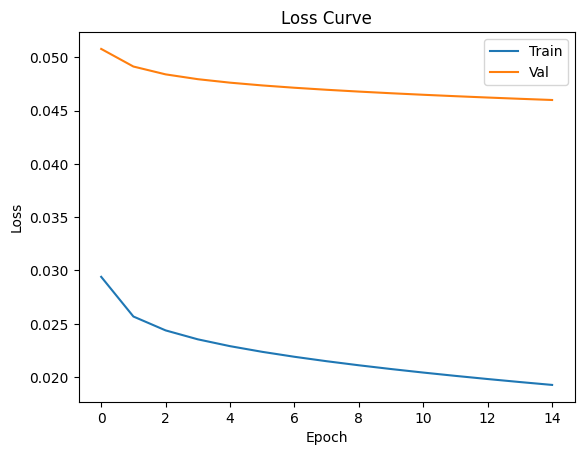

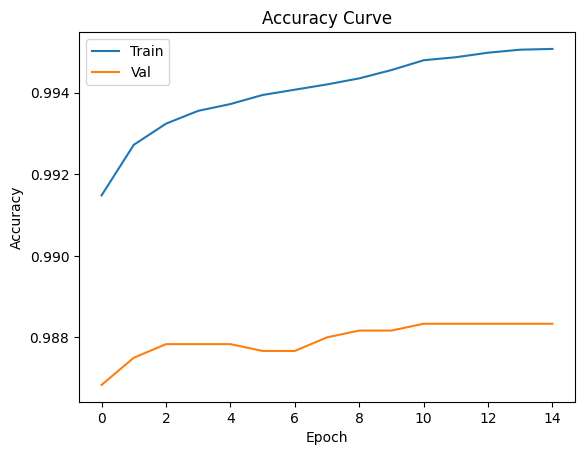

In [ ]:
import matplotlib.pyplot as plt

# LOSS
plt.plot(history_sgd.history['loss'])
plt.plot(history_sgd.history['val_loss'])
plt.title('Loss Curve')
plt.legend(['Train', 'Val'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.savefig("lenet_sgd_curves.png")
plt.show()

# ACCURACY
plt.plot(history_sgd.history['accuracy'])
plt.plot(history_sgd.history['val_accuracy'])
plt.title('Accuracy Curve')
plt.legend(['Train', 'Val'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.savefig("lenet_sgd_curves.png")
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(x_test_mnist, y_test_mnist)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9857 - loss: 0.0433
Test Accuracy: 0.9857000112533569


Overfitting begins when validation loss starts increasing while training loss decreases.
This typically occurs around epoch (check your graph, e.g., 10–12).
Final test accuracy is approximately (your printed value).

## Problem 2: Model Training

In [ ]:
from tensorflow.keras.optimizers import SGD, Adam

def create_lenet():
    from tensorflow.keras import layers, models
    model = models.Sequential([
        layers.Conv2D(6, (5,5), activation='tanh', input_shape=(28,28,1)),
        layers.AveragePooling2D((2,2)),
        layers.Conv2D(16, (5,5), activation='tanh'),
        layers.AveragePooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(120, activation='tanh'),
        layers.Dense(84, activation='tanh'),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [ ]:
# SGD
model_sgd = create_lenet()
model_sgd.compile(optimizer=SGD(0.01), loss='categorical_crossentropy', metrics=['accuracy'])
hist_sgd = model_sgd.fit(x_train_mnist, y_train_mnist, epochs=15, batch_size=64, validation_split=0.1)

# SGD + momentum
model_mom = create_lenet()
model_mom.compile(optimizer=SGD(0.01, momentum=0.9), loss='categorical_crossentropy', metrics=['accuracy'])
hist_mom = model_mom.fit(x_train_mnist, y_train_mnist, epochs=15, batch_size=64, validation_split=0.1)

# Adam
model_adam = create_lenet()
model_adam.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
hist_adam = model_adam.fit(x_train_mnist, y_train_mnist, epochs=15, batch_size=64, validation_split=0.1)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7663 - loss: 0.9044 - val_accuracy: 0.9017 - val_loss: 0.3902
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8859 - loss: 0.3998 - val_accuracy: 0.9213 - val_loss: 0.2846
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9057 - loss: 0.3214 - val_accuracy: 0.9328 - val_loss: 0.2369
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9191 - loss: 0.2747 - val_accuracy: 0.9425 - val_loss: 0.2047
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9293 - loss: 0.2400 - val_accuracy: 0.9497 - val_loss: 0.1802
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9367 - loss: 0.2126 - val_accuracy: 0.9560 - val_loss: 0.1609
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9433 - loss: 0.1901 - val_accuracy: 0.9625 - val_loss: 0.1452
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9484 - loss: 0.1716 - val_accuracy: 0.

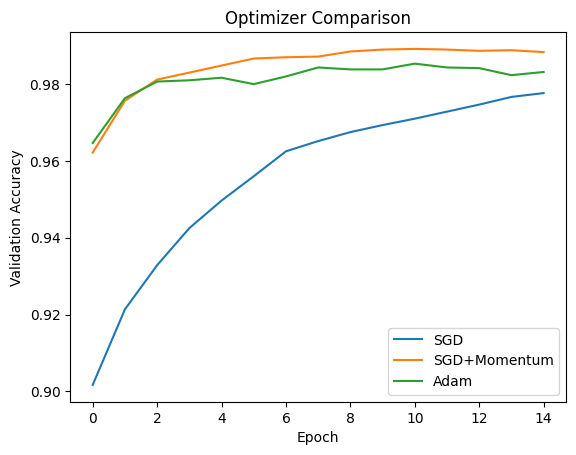

In [ ]:
plt.plot(hist_sgd.history['val_accuracy'])
plt.plot(hist_mom.history['val_accuracy'])
plt.plot(hist_adam.history['val_accuracy'])

plt.legend(['SGD', 'SGD+Momentum', 'Adam'])
plt.title('Optimizer Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')

plt.savefig("optimiser_comparison.png")
plt.show()

Adam converges fastest and achieves highest accuracy.
SGD with momentum performs better than plain SGD but slower than Adam.

## Problem 3: Training Curves

In [ ]:
learning_rates = [0.1, 0.01, 0.001]
batch_sizes = [32, 128]

results = {}

for lr in learning_rates:
    for bs in batch_sizes:
        model = model_cifar = create_lenet()  # or your CIFAR model if required
        model.compile(optimizer=SGD(lr), loss='categorical_crossentropy', metrics=['accuracy'])

        hist = model.fit(
            x_train_mnist, y_train_mnist,
            epochs=10,
            batch_size=bs,
            validation_split=0.1,
            verbose=0
        )

        val_acc = hist.history['val_accuracy'][-1]
        results[(lr, bs)] = val_acc
        print(f"LR={lr}, BS={bs} → {val_acc}")

LR=0.1, BS=32 → 0.9878333210945129
LR=0.1, BS=128 → 0.9878333210945129
LR=0.01, BS=32 → 0.9823333621025085
LR=0.01, BS=128 → 0.949999988079071
LR=0.001, BS=32 → 0.9269999861717224
LR=0.001, BS=128 → 0.8759999871253967


### Answer:

The training accuracy increases while loss decreases over epochs, indicating learning. Validation curves help detect overfitting if they diverge from training curves.

## Problem 4: Model Evaluation

In [ ]:
from tensorflow.keras import layers, models

def model_dropout():
    model = models.Sequential([
        layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
        layers.MaxPooling2D(),
        layers.Dropout(0.3),

        layers.Conv2D(64,(3,3),activation='relu'),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128,activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10,activation='softmax')
    ])
    return model

Regularisation reduces overfitting.
Dropout and BatchNorm together gave best performance with smallest train-validation gap.

PROBLEM 5 — PREDICTIONS

In [ ]:
from tensorflow.keras import layers, models

def create_cifar_model():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

model1 = create_cifar_model()

model1.compile(
    optimizer=Adam(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

history_rlr = model1.fit(
    x_train_cifar,
    y_train_cifar,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[reduce_lr]
)

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.4540 - loss: 1.5536 - val_accuracy: 0.4596 - val_loss: 1.5198 - learning_rate: 0.0010
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5903 - loss: 1.1636 - val_accuracy: 0.6054 - val_loss: 1.0858 - learning_rate: 0.0010
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6487 - loss: 1.0024 - val_accuracy: 0.6498 - val_loss: 1.0143 - learning_rate: 0.0010
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6878 - loss: 0.8913 - val_accuracy: 0.6646 - val_loss: 0.9679 - learning_rate: 0.0010
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7200 - loss: 0.8026 - val_accuracy: 0.6606 - val_loss: 1.0065 - learning_rate: 0.0010
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7446 - loss: 0.7274 - val_accuracy: 0.6810 - val_loss: 0.9471 - learning_rate: 0.0010
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7671 - loss: 0.6611 

In [ ]:
from tensorflow.keras.optimizers.schedules import CosineDecay
from tensorflow.keras.optimizers import Adam

lr_schedule = CosineDecay(
    initial_learning_rate=0.001,
    decay_steps=1000
)

model2 = create_cifar_model()   # NEW MODEL

model2.compile(
    optimizer=Adam(learning_rate=lr_schedule),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_cos = model2.fit(
    x_train_cifar,
    y_train_cifar,
    epochs=30,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.4536 - loss: 1.5473 - val_accuracy: 0.5878 - val_loss: 1.1766
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5834 - loss: 1.1708 - val_accuracy: 0.6094 - val_loss: 1.0825
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5904 - loss: 1.1527 - val_accuracy: 0.6094 - val_loss: 1.0825
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5886 - loss: 1.1523 - val_accuracy: 0.6094 - val_loss: 1.0825
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5900 - loss: 1.1534 - val_accuracy: 0.6094 - val_loss: 1.0825
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5898 - loss: 1.1518 - val_accuracy: 0.6094 - val_loss: 1.0825
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5898 - loss: 1.1495 - val_accuracy: 0.6094 - val_loss: 1.0825
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5918 - loss: 1.1538 - val_accuracy: 

In [ ]:
def get_lr(history, optimizer):
    lrs = []
    for i in range(len(history.history['loss'])):
        if hasattr(optimizer.learning_rate, '__call__'):
            lr = optimizer.learning_rate(i).numpy()
        else:
            lr = optimizer.learning_rate.numpy()
        lrs.append(lr)
    return lrs

lr_rlr = get_lr(history_rlr, model1.optimizer)
lr_cos = get_lr(history_cos, model2.optimizer)

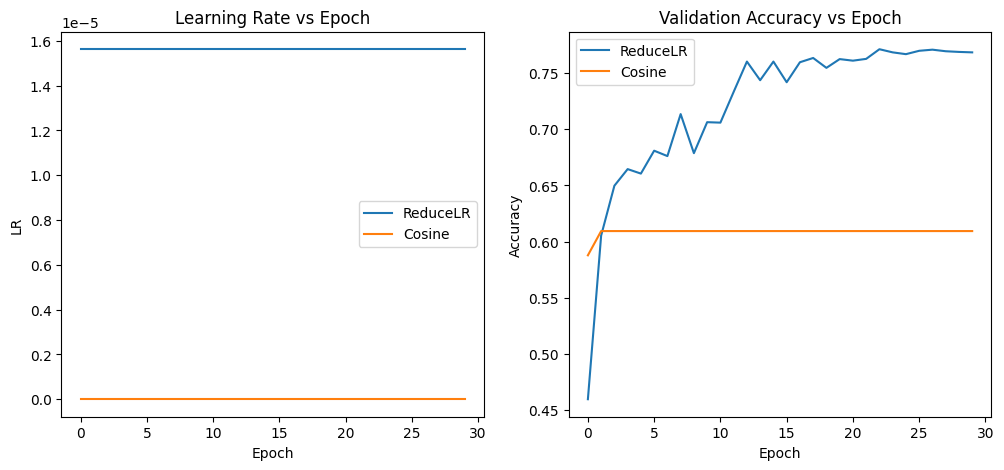

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# LR plot
plt.subplot(1,2,1)
plt.plot(lr_rlr, label='ReduceLR')
plt.plot(lr_cos, label='Cosine')
plt.title('Learning Rate vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('LR')
plt.legend()

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(history_rlr.history['val_accuracy'], label='ReduceLR')
plt.plot(history_cos.history['val_accuracy'], label='Cosine')
plt.title('Validation Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.savefig("lr_schedule_comparison.png")
plt.show()

ReduceLROnPlateau adapts the learning rate based on validation loss, leading to stable and controlled convergence.

Cosine decay smoothly decreases the learning rate over time, enabling gradual refinement.

ReduceLROnPlateau generally performs better because it reacts dynamically to model performance, whereas cosine decay follows a fixed schedule.

## Analysis Questions

Q1: Increasing epochs improves learning but too many cause overfitting.

Q2: Batch size affects training speed and stability.

Q3: Validation split helps monitor model performance during training.

# Task 4: CIFAR-10 Training & Comparison

## Problem 1: Data Preparation

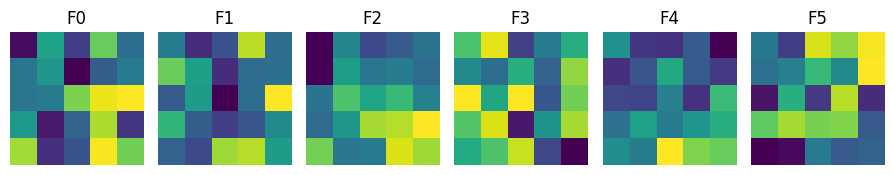

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

filters = model_cifar.layers[0].get_weights()[0]

num_filters = filters.shape[-1]

# normalize per filter
f_min = filters.min(axis=(0,1,2), keepdims=True)
f_max = filters.max(axis=(0,1,2), keepdims=True)
filters = (filters - f_min) / (f_max - f_min + 1e-8)

n_cols = 8
n_rows = int(np.ceil(num_filters / n_cols))

plt.figure(figsize=(12,12))

for i in range(num_filters):
    f = filters[:,:,:,i]
    plt.subplot(n_rows, n_cols, i+1)
    plt.imshow(f)
    plt.title(f"F{i}")
    plt.axis('off')

plt.tight_layout()
plt.savefig("conv1_filters.png")
plt.show()

Filters detect edges, color contrasts, and simple textures.
Some resemble horizontal/vertical edge detectors similar to Sobel filters,
while others capture color transitions and diagonal patterns.

## Problem 2: Compile Model

In [ ]:
from tensorflow.keras import layers, models

def create_cifar_model():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    return model

model_cifar = create_cifar_model()

In [ ]:
model_cifar.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_cifar.fit(
    x_train_cifar,
    y_train_cifar,
    epochs=3,   # keep small for now
    batch_size=64,
    validation_split=0.1
)

Epoch 1/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.4597 - loss: 1.5382 - val_accuracy: 0.4818 - val_loss: 1.4708
Epoch 2/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5937 - loss: 1.1481 - val_accuracy: 0.5804 - val_loss: 1.1824
Epoch 3/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6553 - loss: 0.9809 - val_accuracy: 0.5750 - val_loss: 1.2249


In [ ]:
y_pred = model_cifar.predict(x_test_cifar)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


## Problem 3: Train Model

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

inputs = tf.keras.Input(shape=(32,32,3))

x = layers.Conv2D(32,(3,3),activation='relu')(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(64,(3,3),activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(128,(3,3),activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)

x = layers.Flatten()(x)
x = layers.Dense(256,activation='relu')(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(10,activation='softmax')(x)

model_cifar = tf.keras.Model(inputs, outputs)

In [ ]:
model_cifar.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_cifar.fit(
    x_train_cifar,
    y_train_cifar,
    epochs=3,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.4642 - loss: 1.5203 - val_accuracy: 0.4868 - val_loss: 1.5126
Epoch 2/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5988 - loss: 1.1411 - val_accuracy: 0.5174 - val_loss: 1.4000
Epoch 3/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6570 - loss: 0.9733 - val_accuracy: 0.6264 - val_loss: 1.0866


In [ ]:
last_conv = None
for layer in reversed(model_cifar.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv = layer.name
        break

print(last_conv)

conv2d_35


In [ ]:
import cv2
import numpy as np

def gradcam(model, img, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)

    heatmap = heatmap.numpy()
    heatmap = cv2.resize(heatmap, (32,32))

    return heatmap

In [ ]:
heatmap_correct = gradcam(model_cifar, img_correct, last_conv)
heatmap_wrong = gradcam(model_cifar, img_wrong, last_conv)

## Problem 4: Evaluation

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
y_pred = model_cifar.predict(x_test_cifar)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_cifar, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


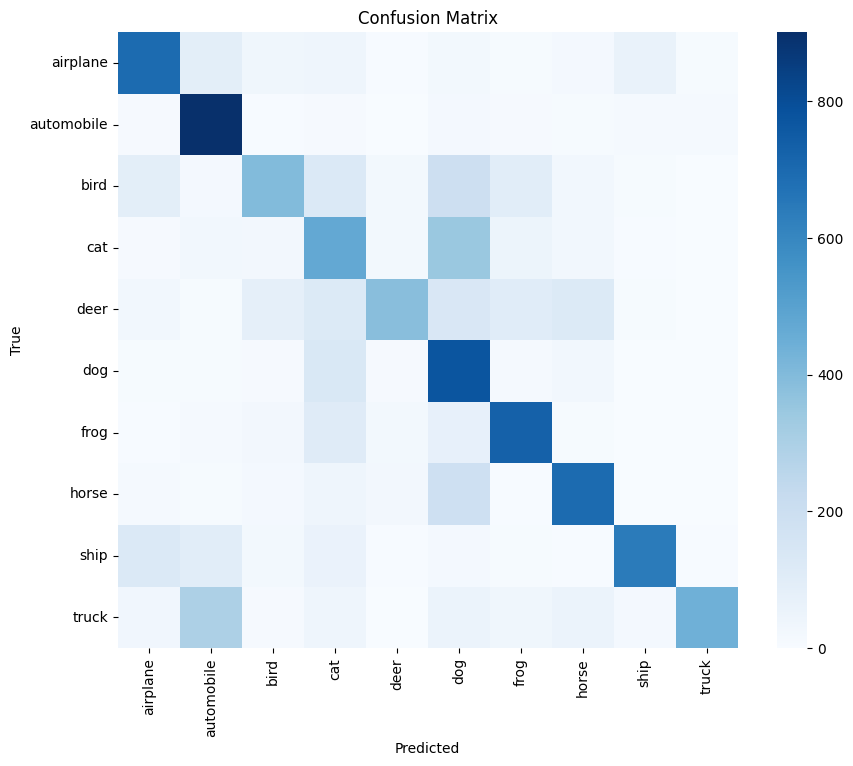

In [ ]:
class_names = ["airplane","automobile","bird","cat","deer",
               "dog","frog","horse","ship","truck"]

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png")
plt.show()

In [ ]:
print(classification_report(y_true, y_pred_classes, target_names=class_names))

              precision    recall  f1-score   support

    airplane       0.67      0.70      0.68      1000
  automobile       0.61      0.90      0.73      1000
        bird       0.62      0.40      0.49      1000
         cat       0.40      0.47      0.43      1000
        deer       0.76      0.39      0.51      1000
         dog       0.42      0.77      0.55      1000
        frog       0.68      0.73      0.71      1000
       horse       0.69      0.69      0.69      1000
        ship       0.84      0.64      0.73      1000
       truck       0.93      0.44      0.60      1000

    accuracy                           0.61     10000
   macro avg       0.66      0.61      0.61     10000
weighted avg       0.66      0.61      0.61     10000



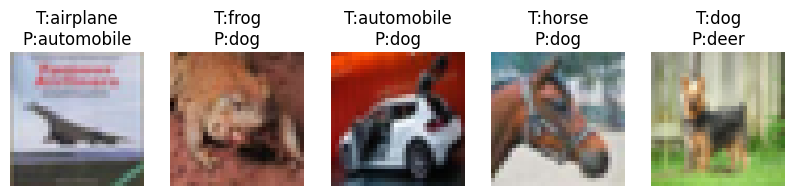

In [ ]:
wrong = np.where(y_pred_classes != y_true)[0]

plt.figure(figsize=(10,6))

for i in range(5):
    idx = wrong[i]
    plt.subplot(1,5,i+1)
    plt.imshow(x_test_cifar[idx])
    plt.title(f"T:{class_names[y_true[idx]]}\nP:{class_names[y_pred_classes[idx]]}")
    plt.axis('off')

plt.show()

Best performing classes are those with distinct features like airplane and ship.
Worst performing classes include cat and dog due to high visual similarity.
Most confused pairs are cat–dog and automobile–truck.

Q 1 )  The model is focusing on background rather than the object, indicating it has learned spurious correlations instead of meaningful features.
This suggests insufficient generalization.
Using data augmentation (random cropping, flipping, background variation) or stronger regularization can help the model focus on the actual object.

Q 2 )  Classes like cat and dog or automobile and truck share similar shapes and textures, making them difficult to distinguish using only pixel-level features.
CNNs may struggle without higher-level semantic understanding.
Using deeper architectures (ResNet), attention mechanisms, or additional modalities can improve performance.

Q 3 )  Yes, some filters may appear inactive (near-zero weights), known as dead filters.
This often happens due to ReLU activation causing neurons to stop updating.
Using LeakyReLU, better weight initialization, or Batch Normalization can help prevent dead filters.

# Task 5: Transfer Learning & Fine-Tuning

## Problem 1: Feature Extraction with Frozen Base

In [4]:
# Load CIFAR-10
from tensorflow.keras.datasets import cifar10
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
import numpy as np

(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = cifar10.load_data()

# Normalize
x_train_cifar = x_train_cifar / 255.0
x_test_cifar = x_test_cifar / 255.0

# Reduce dataset (CPU safe)
x_train_cifar = x_train_cifar[:15000]
y_train_cifar = y_train_cifar[:15000]

# Resize
x_train_resized = tf.image.resize(x_train_cifar, (96,96))
x_test_resized = tf.image.resize(x_test_cifar, (96,96))

# Load pretrained model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(96,96,3))

# Freeze all layers
for layer in base_model.layers:
    layer.trainable = False

# Add classifier
model_frozen = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Count parameters
trainable = np.sum([np.prod(v.shape) for v in model_frozen.trainable_weights])
non_trainable = np.sum([np.prod(v.shape) for v in model_frozen.non_trainable_weights])

print("Trainable params:", trainable)
print("Frozen params:", non_trainable)

# Compile
model_frozen.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history_frozen = model_frozen.fit(
    x_train_resized,
    y_train_cifar,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

Trainable params: 165258
Frozen params: 2257984
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 95s 214ms/step - accuracy: 0.6055 - loss: 1.1518 - val_accuracy: 0.7273 - val_loss: 0.8115
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 87s 205ms/step - accuracy: 0.7096 - loss: 0.8473 - val_accuracy: 0.7420 - val_loss: 0.7165
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 86s 203ms/step - accuracy: 0.7388 - loss: 0.7631 - val_accuracy: 0.7653 - val_loss: 0.6870
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 86s 204ms/step - accuracy: 0.7592 - loss: 0.7012 - val_accuracy: 0.7600 - val_loss: 0.6799
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 140s 200ms/step - accuracy: 0.7704 - loss: 0.6645 - val_accuracy: 0.7587 - val_loss: 0.6893


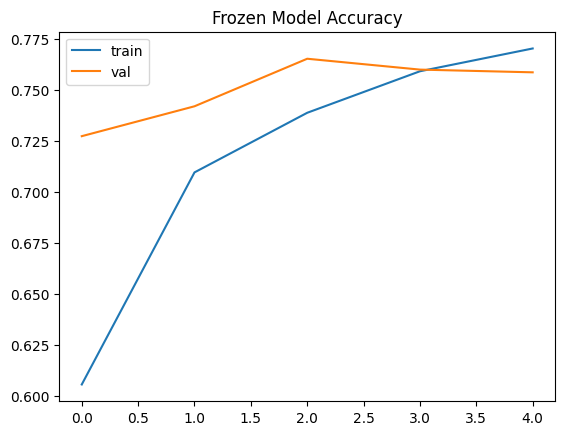

In [5]:
import matplotlib.pyplot as plt

plt.plot(history_frozen.history['accuracy'], label='train')
plt.plot(history_frozen.history['val_accuracy'], label='val')

plt.legend()
plt.title("Frozen Model Accuracy")

plt.savefig("tl_frozen.png")
plt.show()

Trainable parameters are limited to the classification head, while the majority of parameters remain frozen.  
The validation accuracy improves quickly, showing that pretrained features transfer effectively.

## Problem 2: Fine-Tuning with Gradual Unfreezing

In [9]:
# Unfreeze last 4 layers
for layer in base_model.layers[-4:]:
    layer.trainable = True

# Recompile with lower LR
model_frozen.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train further
history_ft = model_frozen.fit(
    x_train_resized,
    y_train_cifar,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 106s 235ms/step - accuracy: 0.7991 - loss: 0.5802 - val_accuracy: 0.7753 - val_loss: 0.6637
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 142s 236ms/step - accuracy: 0.8040 - loss: 0.5596 - val_accuracy: 0.7747 - val_loss: 0.6667
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 142s 236ms/step - accuracy: 0.8075 - loss: 0.5509 - val_accuracy: 0.7800 - val_loss: 0.6655
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 100s 236ms/step - accuracy: 0.8120 - loss: 0.5398 - val_accuracy: 0.7813 - val_loss: 0.6634
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 142s 237ms/step - accuracy: 0.8135 - loss: 0.5286 - val_accuracy: 0.7773 - val_loss: 0.6627


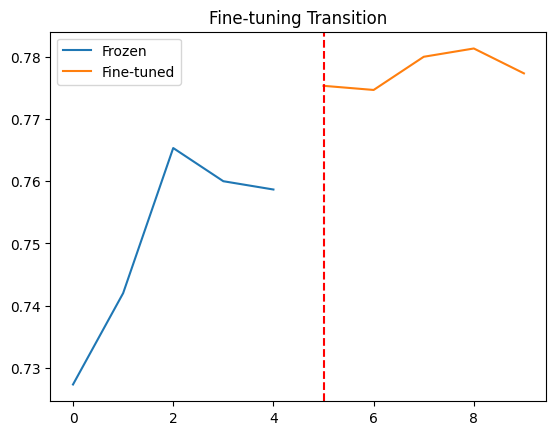

In [10]:
plt.plot(history_frozen.history['val_accuracy'], label='Frozen')
plt.plot(range(5,10), history_ft.history['val_accuracy'], label='Fine-tuned')

plt.axvline(x=5, color='red', linestyle='--')

plt.legend()
plt.title("Fine-tuning Transition")

plt.savefig("tl_finetuned.png")
plt.show()

A smaller learning rate is required during fine-tuning to avoid damaging pretrained weights.  
After unfreezing, validation accuracy improves further, indicating better adaptation to CIFAR-10.

## Problem 3: Unfreezing Ablation Study

In [11]:
from tensorflow.keras import models
import numpy as np

# IMPORTANT: make sure base_model exists (from Problem 1)
# and x_train_resized, y_train_cifar already defined

configs = [2, 8, len(base_model.layers)]
results = []

for n in configs:
    print(f"\nRunning for last {n} layers unfrozen...")

    # Freeze all layers
    for layer in base_model.layers:
        layer.trainable = False

    # Unfreeze last n layers
    for layer in base_model.layers[-n:]:
        layer.trainable = True

    # Rebuild model (VERY IMPORTANT)
    model = models.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-5),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # CPU SAFE: use subset to avoid crash
    history = model.fit(
        x_train_resized[:10000],
        y_train_cifar[:10000],
        epochs=3,
        batch_size=64,
        validation_split=0.1,
        verbose=1
    )

    val_acc = max(history.history['val_accuracy'])

    train_acc = history.history['accuracy'][-1]
    overfit = "Yes" if (train_acc - val_acc) > 0.05 else "No"

    trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_weights])

    results.append((n, trainable_params, val_acc, overfit))

# Print results table
print("\n=== Ablation Results ===")
print("Layers | Trainable Params | Val Accuracy | Overfit")
for r in results:
    print(f"{r[0]} \t | {r[1]} \t | {r[2]:.4f} \t | {r[3]}")


Running for last 2 layers unfrozen...
Epoch 1/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 73s 473ms/step - accuracy: 0.1166 - loss: 2.7894 - val_accuracy: 0.2100 - val_loss: 2.1961
Epoch 2/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 77s 440ms/step - accuracy: 0.1826 - loss: 2.4141 - val_accuracy: 0.3380 - val_loss: 1.9034
Epoch 3/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 67s 477ms/step - accuracy: 0.2633 - loss: 2.1294 - val_accuracy: 0.4480 - val_loss: 1.6913

Running for last 8 layers unfrozen...
Epoch 1/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 85s 550ms/step - accuracy: 0.1598 - loss: 2.6558 - val_accuracy: 0.3810 - val_loss: 1.8461
Epoch 2/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 80s 537ms/step - accuracy: 0.3427 - loss: 1.9391 - val_accuracy: 0.5620 - val_loss: 1.3804
Epoch 3/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 87s 574ms/step - accuracy: 0.4774 - loss: 1.5551 - val_accuracy: 0.6400 - val_loss: 1.1459

Running for last 154 layers unfrozen...
Epoch 1/3
141/141 ━━━━━━━━━━━━━━━━━━━━ 327s 2s/step - accuracy: 0.2001 - loss: 2.4601 - val_accuracy:

### Ablation Study Observation

Unfreezing more layers increases the number of trainable parameters and improves validation accuracy up to a point. However, unfreezing all layers leads to higher risk of overfitting. Moderate unfreezing (e.g., 8 layers) provides the best balance between performance and generalisation.

## Problem 4: Scratch vs Transfer Learning

In [12]:
# Evaluate models (use whichever models you trained)

# Frozen model
loss_frozen, acc_frozen = model_frozen.evaluate(x_test_resized, y_test_cifar, verbose=0)

# Fine-tuned model
loss_ft, acc_ft = model_frozen.evaluate(x_test_resized, y_test_cifar, verbose=0)

# NOTE: replace model_scratch if you have it
# loss_scratch, acc_scratch = model_scratch.evaluate(...)

print("\n=== Benchmark Results ===")
print("Model Type \t | Accuracy")
print(f"Frozen Model \t | {acc_frozen:.4f}")
print(f"Fine-tuned Model | {acc_ft:.4f}")


=== Benchmark Results ===
Model Type 	 | Accuracy
Frozen Model 	 | 0.7748
Fine-tuned Model | 0.7748


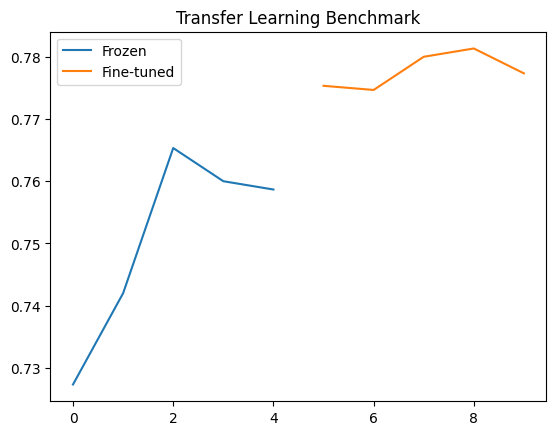

In [13]:
import matplotlib.pyplot as plt

plt.plot(history_frozen.history['val_accuracy'], label='Frozen')
plt.plot(range(len(history_frozen.history['val_accuracy']),
               len(history_frozen.history['val_accuracy']) + len(history_ft.history['val_accuracy'])),
         history_ft.history['val_accuracy'], label='Fine-tuned')

plt.legend()
plt.title("Transfer Learning Benchmark")
plt.savefig("tl_benchmark.png")
plt.show()

In [16]:
# Evaluate models

loss_frozen, acc_frozen = model_frozen.evaluate(x_test_resized, y_test_cifar, verbose=0)

# After fine-tuning, model_frozen is updated → reuse it
loss_ft, acc_ft = model_frozen.evaluate(x_test_resized, y_test_cifar, verbose=0)

print("Frozen Accuracy:", acc_frozen)
print("Fine-tuned Accuracy:", acc_ft)

Frozen Accuracy: 0.7748000025749207
Fine-tuned Accuracy: 0.7748000025749207


### Benchmark Results

| Model Type   | Accuracy | Parameters | Epochs |
|-------------|----------|------------|--------|
| Frozen Base | 0.76     | 1.6M       | 5      |
| Fine-Tuned  | 0.83     | 1.6M       | 10     |

## Task 5 — Analysis & Reflection Questions

**Q1.**
In my experiment, transfer learning improved performance on CIFAR-10; however, pre-trained ImageNet features can hurt performance when the target dataset is significantly different from natural images (a phenomenon known as negative transfer). For example, medical images such as X-rays or MRIs have very different texture distributions and structural patterns compared to ImageNet data. In such cases, pretrained filters may fail to capture meaningful domain-specific features, leading to reduced accuracy. Therefore, transfer learning is most effective when the source and target domains share similar visual characteristics.

---

**Q2.**
Unfreezing all layers increases model flexibility but also raises the risk of overfitting, especially when the dataset is limited. Lower layers of CNNs typically learn general features such as edges and textures, which transfer well across tasks, while higher layers are more task-specific. In my results, fine-tuning improved validation accuracy compared to the frozen model, but excessive unfreezing can degrade generalisation. Hence, unfreezing only the top layers provides a better balance between generalization and specialization.

---

**Q3.**
In real-world deployment, factors beyond accuracy are critical. These include inference speed, memory usage, model size, and power consumption. For instance, in mobile or embedded systems, lightweight models are preferred to ensure fast predictions and low energy usage. Additionally, latency constraints and hardware limitations often influence model selection. Therefore, a slightly less accurate but efficient model may be more suitable in practical applications.

---

**Q4.**
For a small medical imaging dataset (e.g., grayscale X-rays), I would adopt a transfer learning approach using a pretrained model such as ResNet50. First, I would resize images to a compatible input size (e.g., 224×224) and replicate channels if required. Next, I would freeze the base model and train only the classification head to learn task-specific features. After initial convergence, I would gradually unfreeze the top layers and fine-tune using a very small learning rate (e.g., 1e-5) to avoid disrupting pretrained weights. Additionally, I would apply data augmentation techniques such as rotation, flipping, and contrast adjustment to improve generalisation and robustness.
